<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif;">

<h1 style="color: #004080; border-bottom: 3px solid #004080; padding-bottom: 10px; font-weight: 800; margin-top: 0;">
    Aquaverse Short Course Part II: Generating MDN Predictions
</h1>

<p style="font-size: 1.15em; line-height: 1.7; color: #222222;">
    This notebook illustrates how to use the pretrained <b>Mixture Density Network (MDN)</b> models within the Aquaverse framework to generate predictions of selected Water Quality (WQ) parameters on your own data. The notebook will explain how to generate predictions/results from both <i>in situ/spectral</i> data as well as from <i>satellite/cube</i> data. This notebook will also present a comparison of the MDN's performance versus standard operational algorithms for some variables.
</p>

<p style="font-size: 1.15em; line-height: 1.7; color: #222222;">
    The satellite-derived products for Sentinel-2 MultiSpectral Instrument (MSI) and Landsat-8/9 Operational Land Imager (OLI) are directly available for download via the <a href="https://ladsweb.modaps.eosdis.nasa.gov/stream/" target="_blank" style="color:#0056b3;text-decoration:underline;font-weight:bold;">Satellite-based Tool for Rapid Evaluation of Aquatic environMents (STREAM)</a> website. The Aquaverse toolbox also supports other satellite-product combinations, which are also mentioned in this notebook.
</p>

<h3 style="color: #004080; margin-top: 25px;"><b>Course Objectives</b></h3>
<ul style="line-height: 1.9; color: #1a1a1a; list-style-type: none; padding-left: 0;">
    <li><span style="color: #d35400;">■</span> <b>01. Supported Combinations:</b> List all the available sensor-product combinations that are supported by the current Aquaverse toolbox.</li>
    <li><span style="color: #d35400;">■</span> <b>02. Spectral Estimation:</b> Leverage the <a href="https://doi.pangaea.de/10.1594/PANGAEA.948492" target="_blank" style="color: #0056b3; text-decoration: underline; font-weight: bold;">GLORIA dataset</a> to show how the Aquaverse toolbox can be used to extract WQ estimates from <i>in situ/spectral</i> <span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000; font-size: 1.1em;">R<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">rs</sub></span> data.</li>
    <li><span style="color: #d35400;">■</span> <b>03. Architecture:</b> Understand MDN structures and output parameterization.</li>
    <li><span style="color: #d35400;">■</span> <b>04. Satellite data download:</b> Download some example satellite <span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000; font-size: 1.1em;">R<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">rs</sub></span> cubes to use for testing with the Aquaverse toolbox.</li>
    <li><span style="color: #d35400;">■</span> <b>05. Satellite product estimates:</b> Visualize MDN outputs from satellite <span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000; font-size: 1.1em;">R<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">rs</sub></span> cubes, both the pixel estimates as well as the associated uncertainties.</li>
</ul>

<div style="background-color: #fcf8e3; color: #8a6d3b; padding: 15px; border: 1px solid #faebcc; border-left: 6px solid #8a6d3b; margin: 20px 0; font-weight: 500;">
    <strong>Requirement:</strong> Assumes that the user has already run the first notebook in this tutorial (<a href="AQV_1_MDN_explained.ipynb" style="color: #0056b3; text-decoration: underline; font-weight: bold;">AQV_1_MDN_explained.ipynb</a>) and has already correctly installed the toolbox and downloaded the <a href="https://doi.pangaea.de/10.1594/PANGAEA.948492" target="_blank" style="color: #0056b3; text-decoration: underline; font-weight: bold;">GLORIA dataset</a>.
</div>

<hr style="border: 0; border-top: 2px solid #eee;">

<div style="margin-bottom: 20px;">
    <strong style="color: #004080; font-size: 1.1em;">Freshwater Sensing Group</strong><br>
    <span style="color: #444;">Science Systems and Applications, Inc. / NASA Goddard Space Flight Center</span><br>
    <span style="color: #666;">August 2026</span>
</div>

<h4 style="color: #004080; margin-bottom: 10px;">Technical Contacts</h4>
<table style="width: 100%; border-collapse: collapse; border: 1px solid #ddd;">
    <thead style="background-color: #f2f2f2;">
        <tr>
            <th style="text-align: left; padding: 12px; border: 1px solid #ddd; color: #004080;">Domain</th>
            <th style="text-align: left; padding: 12px; border: 1px solid #ddd; color: #004080;">Section Lead</th>
            <th style="text-align: left; padding: 12px; border: 1px solid #ddd; color: #004080;">Email</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 10px; border: 1px solid #ddd; font-weight: 500;">BPs & IOP Products</td>
            <td style="padding: 10px; border: 1px solid #ddd;">Ryan E. O'Shea</td>
            <td style="padding: 10px; border: 1px solid #ddd;"><a href="mailto:ryan.oshea@ssaihq.com" style="color: #0056b3; font-weight: bold;">ryan.oshea@ssaihq.com</a></td>
        </tr>
        <tr style="background-color: #fafafa;">
            <td style="padding: 10px; border: 1px solid #ddd; font-weight: 500;">Uncertainties</td>
            <td style="padding: 10px; border: 1px solid #ddd;">Arun Saranathan</td>
            <td style="padding: 10px; border: 1px solid #ddd;"><a href="mailto:arun.saranathan@ssaihq.com" style="color: #0056b3; font-weight: bold;">arun.saranathan@ssaihq.com</a></td>
        </tr>
        <tr>
            <td style="padding: 10px; border: 1px solid #ddd; font-weight: 500;">Atmospheric Correction</td>
            <td style="padding: 10px; border: 1px solid #ddd;">Akash Ashapure</td>
            <td style="padding: 10px; border: 1px solid #ddd;"><a href="mailto:akash.ashapure@ssaihq.com" style="color: #0056b3; font-weight: bold;">akash.ashapure@ssaihq.com</a></td>
        </tr>
        <tr>
            <td style="padding: 10px; border: 1px solid #ddd; font-weight: 500;">Stream Website</td>
            <td style="padding: 10px; border: 1px solid #ddd;">William Wainwright</td>
            <td style="padding: 10px; border: 1px solid #ddd;"><a href="mailto:william.wainwright@ssaihq.com" style="color: #0056b3; font-weight: bold;">william.wainwright@ssaihq.com</a></td>
        </tr>
    </tbody>
</table>

</div>

<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6;">

<h2 style="color: #c0392b; border-bottom: 2px solid #c0392b; padding-bottom: 8px; font-weight: 700; margin-top: 0;">
    Section 1: Available satellite product pairs for WQ estimation
</h2>

<p style="font-size: 1.15em; color: #222222;">
    Import the Aquaverse <code>MDN</code> WQ package included with this course. Then we will print/visualize the available satellite-product combination supported by this package at the currnet stage. The product pairs visualized in this section correspond to the combinations made public by the Aquaverse team. If you would like to inquire about a specific combination not shown here contact the Aquaverse team for support with the combination you need.
</p>

<div style="background-color: #e8f4fd; color: #2b5797; padding: 15px; border: 1px solid #d2e3f7; border-left: 6px solid #2b5797; margin: 20px 0;">
    <strong style="font-size: 1.1em;">Technical Note:</strong> 
    The following cell performs the import of all functions needed by this notebook, not just the ones needed by this section.
</div>


<hr style="border: 0; border-top: 1px solid #eee; margin: 20px 0;">

<div style="font-size: 0.9em; color: #666; font-style: italic; text-align: right;">
    Aquaverse Short Course • Module 2.1
</div>

</div>

In [1]:
# Import the base python packages needed for this notebook
import numpy                                                          as np
import scipy
import os
import subprocess
from   pathlib                    import Path
from   urllib.request             import urlretrieve
import zipfile
import matplotlib                                                     as mpl
import matplotlib.pyplot                                              as plt
import matplotlib.patches                                             as patches
from   matplotlib                 import ticker
from   matplotlib.colors          import LogNorm
import sys
sys.path.append("C:\\Users\\asaranat\\OneDrive - NASA\\Code\\MDN-STREAM\\")

# Supressing tensorflow based warnings
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=UserWarning)
import tensorflow as tf
tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)
logging.getLogger('tensorflow_probability').setLevel(logging.ERROR)

# Import some specific functions and packages from MDN implementation
from   MDN                        import get_sensor_bands, get_tile_data
from   MDN                        import current_support 
from   MDN                        import get_gloria_trainTestData, get_args
from   MDN                        import get_spectral_preds
from   MDN                        import create_scatterplots_trueVsPred, performance
from   MDN                        import OC, resample_Rrs 

[compat_patch] NumPy version: 2.3.3
[compat_patch] Applied NumPy _randomstate_ctor patch.
[compat_patch] TensorFlow version: 2.20.0
[compat_patch] Applied TensorFlow TrackableReference patch (tracking.base).
[compat_patch] NumPy version: 2.3.3
[compat_patch] TensorFlow version: 2.20.0
Modified RC Params: dict_keys(['backend'])


In [2]:
'Print all the product/sensor model combinations available in the current MDN tool box'
### need to modify this function to only print sensor and product combinations that are available in the current MDN tool box
current_support()

Model-1: predicts chl,tss,cdom from OLI data
Model-2: predicts chl from OLI data
Model-3: predicts chl,tss,cdom from OLCI data
Model-4: predicts chl from OLCI data
Model-5: predicts chl,tss,cdom from MSI data
Model-6: predicts chl from MSI data
Model-7: predicts chl,tss,cdom,pc from S3A data
Model-8: predicts chl,tss,cdom,pc from S3B data
Model-9: predicts aph,chl,tss,pc,ad,ag,cdom from HICO data
Model-10: predicts aph,chl,tss,pc,ad,ag,cdom from PRISMA data
Model-11: predicts aph,chl,tss,pc,ad,ag,cdom from PACE data
Model-12: predicts aph,chl,tss,pc,ad,ag,cdom from PACE-sat data
Model-13: predicts Chl,TSS,aCDOM443,aCDOM555,aNAP443,aNAP555,aph443,aph488,aph555,aph667 from VI data
Model-14: predicts Chl,TSS,aCDOM443,aCDOM555,aNAP443,aNAP555,aph443,aph488,aph555,aph667 from MOD data
Model-15: predicts Chl,TSS,aCDOM443,aCDOM555,aNAP443,aNAP555,aph443,aph488,aph555,aph667 from MERIS data


<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; box-sizing: border-box; max-width: 100%; word-wrap: break-word; overflow-wrap: break-word;">

<h4 style="color: #004080; margin-top: 0; margin-bottom: 15px; font-weight: 700;">Supported Sensor-Product Matrix</h4>

<div style="width: 100%; overflow-x: auto; margin-bottom: 20px; box-sizing: border-box;">
    <table style="width: 100%; min-width: 800px; border-collapse: collapse; border: 1px solid #ddd; font-size: 0.95em;">
        <thead style="background-color: #f2f2f2;">
            <tr>
                <th style="text-align: left; padding: 12px; border: 1px solid #ddd; color: #004080; font-weight: 600;">Product</th>
                <th style="text-align: center; padding: 6px; border: 1px solid #ddd; color: #004080; font-weight: 600;">OLI</th>
                <th style="text-align: center; padding: 6px; border: 1px solid #ddd; color: #004080; font-weight: 600;">OLCI</th>
                <th style="text-align: center; padding: 6px; border: 1px solid #ddd; color: #004080; font-weight: 600;">MSI</th>
                <th style="text-align: center; padding: 6px; border: 1px solid #ddd; color: #004080; font-weight: 600;">S3A / S3B</th>
                <th style="text-align: center; padding: 6px; border: 1px solid #ddd; color: #004080; font-weight: 600;">HICO</th>
                <th style="text-align: center; padding: 6px; border: 1px solid #ddd; color: #004080; font-weight: 600;">PRISMA</th>
                <th style="text-align: center; padding: 6px; border: 1px solid #ddd; color: #004080; font-weight: 600;">PACE (sat)</th>
                <th style="text-align: center; padding: 6px; border: 1px solid #ddd; color: #004080; font-weight: 600;">VIIRS</th>
                <th style="text-align: center; padding: 6px; border: 1px solid #ddd; color: #004080; font-weight: 600;">MODIS</th>
                <th style="text-align: center; padding: 6px; border: 1px solid #ddd; color: #004080; font-weight: 600;">MERIS</th>
            </tr>
        </thead>
        <tbody>
            <tr>
                <td style="padding: 10px; border: 1px solid #ddd; font-weight: 600; color: #333;">Chl <span style="font-weight: normal; color: #666; font-size: 0.9em;">(Chlorophyll-a)</span></td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
            </tr>
            <tr style="background-color: #fafafa;">
                <td style="padding: 10px; border: 1px solid #ddd; font-weight: 600; color: #333;">TSS <span style="font-weight: normal; color: #666; font-size: 0.9em;">(Total Suspended Solids)</span></td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
            </tr>
            <tr>
                <td style="padding: 10px; border: 1px solid #ddd; font-weight: 600; color: #333;">CDOM / aCDOM <span style="font-weight: normal; color: #666; font-size: 0.9em;">(Absorption)</span></td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; font-size: 0.85em; color: #333;">✓ <span style="color:#666; display:block; font-size:0.9em;">(440 nm)</span></td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; font-size: 0.85em; color: #333;">✓ <span style="color:#666; display:block; font-size:0.9em;">(440 nm)</span></td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; font-size: 0.85em; color: #333;">✓ <span style="color:#666; display:block; font-size:0.9em;">(440 nm)</span></td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; font-size: 0.85em; color: #333;">✓ <span style="color:#666; display:block; font-size:0.9em;">(440 nm)</span></td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; font-size: 0.85em; color: #333;">✓ <span style="color:#666; display:block; font-size:0.9em;">(443/555)</span></td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; font-size: 0.85em; color: #333;">✓ <span style="color:#666; display:block; font-size:0.9em;">(443/555)</span></td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; font-size: 0.85em; color: #333;">✓ <span style="color:#666; display:block; font-size:0.9em;">(443/555)</span></td>
            </tr>
            <tr style="background-color: #fafafa;">
                <td style="padding: 10px; border: 1px solid #ddd; font-weight: 600; color: #333;">PC <span style="font-weight: normal; color: #666; font-size: 0.9em;">(Phycocyanin)</span></td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
            </tr>
            <tr>
                <td style="padding: 10px; border: 1px solid #ddd; font-weight: 600; color: #333;">aph <span style="font-weight: normal; color: #666; font-size: 0.9em;">(Phytoplankton Abs.)</span></td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; font-size: 0.8em; color: #333;">✓ <span style="color:#666; display:block; font-size:0.85em;">(443/488/555/667)</span></td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; font-size: 0.8em; color: #333;">✓ <span style="color:#666; display:block; font-size:0.85em;">(443/488/555/667)</span></td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; font-size: 0.8em; color: #333;">✓ <span style="color:#666; display:block; font-size:0.85em;">(443/488/555/667)</span></td>
            </tr>
            <tr style="background-color: #fafafa;">
                <td style="padding: 10px; border: 1px solid #ddd; font-weight: 600; color: #333;">ad / ag <span style="font-weight: normal; color: #666; font-size: 0.9em;">(Detritus / Gelbstoff)</span></td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #27ae60; font-weight: bold;">✓</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
            </tr>
            <tr>
                <td style="padding: 10px; border: 1px solid #ddd; font-weight: 600; color: #333;">aNAP <span style="font-weight: normal; color: #666; font-size: 0.9em;">(Non-Algal Particle Abs.)</span></td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; color: #ccc;">—</td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; font-size: 0.85em; color: #333;">✓ <span style="color:#666; display:block; font-size:0.9em;">(443/555)</span></td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; font-size: 0.85em; color: #333;">✓ <span style="color:#666; display:block; font-size:0.9em;">(443/555)</span></td>
                <td style="padding: 10px; border: 1px solid #ddd; text-align: center; font-size: 0.85em; color: #333;">✓ <span style="color:#666; display:block; font-size:0.9em;">(443/555)</span></td>
            </tr>
        </tbody>
    </table>
</div>

<div style="background-color: #e8f4fd; color: #2b5797; padding: 15px; border: 1px solid #d2e3f7; border-left: 6px solid #2b5797; margin: 20px 0; box-sizing: border-box;">
    <strong style="font-size: 1.1em;">Methodology Note:</strong> 
    Unless explicitly noted above, the parameters 
    <span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000; font-size: 1.1em;">a<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">d</sub></span>, 
    <span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000; font-size: 1.1em;">a<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">NAP</sub></span>, 
    <span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000; font-size: 1.1em;">a<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">CDOM</sub></span>, and 
    <span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000; font-size: 1.1em;">a<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">ph</sub></span> 
    are hyperspectral at the resolution of the sensor.
</div>

<div style="background-color: #fdf2f2; color: #9b1c1c; padding: 15px; border: 1px solid #f8b4b4; border-left: 6px solid #e11d48; margin: 20px 0; box-sizing: border-box; border-radius: 4px;">
    <strong style="font-size: 1.1em;">Internal Note: Things to change in this section</strong>
    <ol style="margin-top: 5px; margin-bottom: 0; padding-left: 20px;">
        <li>Combine S3A and S3B into OLCI.</li>
        <li>Why do we use the instrument name for all others and the platform name for PACE?</li>
        <li>Change the <code>current_support</code> function to only print the sensor-product combinations.</li>
        <li> Need to add to Zsd to this also.
        <li> Need to add citations/links for the operational algorithms. </li>
    </ol>
</div>

</div>

<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6;">

<p style="font-size: 1.15em; color: #222222; margin-top: 0;">
    The following cell is used setup the matplotlib environment for displaying the results in this notebook.
</p>


</div>

In [3]:
# Set display parameters via MATPLOTLIB for this notebook
plt.rcParams.update({"text.usetex": False,})
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

plt.rcParams['mathtext.default'] = 'regular'
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 16
mrkSize = 15
ASPECT = "auto"
cmap = "jet"

mpl.rcParams['xtick.labelsize'] = SMALL_SIZE
mpl.rcParams['ytick.labelsize'] = SMALL_SIZE

plt.rc('font', size=SMALL_SIZE)  # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)  # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)

<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6; box-sizing: border-box; max-width: 100%; word-wrap: break-word; overflow-wrap: break-word;">

<h2 style="color: #c0392b; border-bottom: 2px solid #c0392b; padding-bottom: 8px; font-weight: 700; margin-top: 0;">
    Section 2: Obtaining in situ samples from GLORIA
</h2>

<p style="font-size: 1.15em; color: #222222;">
    One way to use the <code>MDN</code> WQ package is to generate predictions from spectral data. Such data may come from <i>in situ</i> <span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000; font-size: 1.1em;">R<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">rs</sub></span> measurements at selected locations or a set of user-selected satellite pixel <span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000; font-size: 1.1em;">R<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">rs</sub></span>. In either case, the dataset we want to use for predictions is structured as a 2D array. This section will walk you through how to generate predictions for these datasets and how to visualize them.
</p>

<div style="background-color: #e8f4fd; color: #2b5797; padding: 15px; border: 1px solid #d2e3f7; border-left: 6px solid #2b5797; margin: 20px 0; box-sizing: border-box;">
    <strong style="font-size: 1.1em;">Technical Note:</strong> 
    For this demo, we will use the <i>in situ</i> <span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000; font-size: 1.1em;">R<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">rs</sub></span> from the <a href="https://doi.pangaea.de/10.1594/PANGAEA.948492" target="_blank" style="color: #0056b3; text-decoration: underline; font-weight: bold;">GLORIA dataset</a> as our spectral data. Because these <span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000; font-size: 1.1em;">R<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">rs</sub></span> data also feature collocated measurements of WQ parameters, this dataset can be used to evaluate model performance. For this demo, we will also resample the data to the spectral resolution of the Sentinel-3 OLCI.
</div>

<hr style="border: 0; border-top: 1px solid #eee; margin: 20px 0;">

<div style="font-size: 0.9em; color: #666; font-style: italic; text-align: right;">
    Aquaverse Short Course • Module 2.2
</div>

</div>

In [4]:
# Set the GLORIA folder and extract the data
gloria_folder = Path().cwd() / 'data/GLORIA_2022/'

assert gloria_folder.is_dir(), f"No folder found art {gloria_folder}"

# Set the sensor we want to work with
sensor = "OLCI"
products = "chl,tss"

# Get the GLORIA data at the resolution of the OLCI sensor
x_data, y_data, gid_data = get_gloria_trainTestData(sensor=sensor, out_var=products.split(','),
                                                    save_flag=False, load_exists=False,rand_seed=42,
                                                    rem_flagged=True, gloria_folder=gloria_folder,
                                                    flag_name='GLORIA_qc_flags.csv', rrs_name='GLORIA_Rrs.csv',
                                                    bg_name='GLORIA_meta_and_lab.csv', gloria_only=True,
                                                    train_mode=False)


Bands with responses outside of range [350, 899]: 
 [np.float64(900.0), np.float64(940.0), np.float64(1020.0)]

Creating data for bands
 [np.float64(400.0), np.float64(412.5), np.float64(442.5), np.float64(490.0), np.float64(510.0), np.float64(560.0), np.float64(620.0), np.float64(665.0), np.float64(673.75), np.float64(681.25), np.float64(708.75), np.float64(753.75), np.float64(761.25), np.float64(764.375), np.float64(767.5), np.float64(778.75), np.float64(865.0), np.float64(885.0)]


100%|██████████| 7572/7572 [00:06<00:00, 1212.09it/s]


<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6; box-sizing: border-box; max-width: 100%; word-wrap: break-word; overflow-wrap: break-word;">

<h2 style="color: #c0392b; border-bottom: 2px solid #c0392b; padding-bottom: 8px; font-weight: 700; margin-top: 0;">
    Section 3: Generating predictions on spectral data
</h2>

<p style="font-size: 1.15em; color: #222222;">
    To derive water quality estimates from input spectra, the package provides the primary function <code>get_spectral_preds</code>. Based on the target sensor and requested products, the optimal model is <b>auto-selected</b> from the suite of available trained networks. This function processes 2D arrays of <span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000; font-size: 1.1em;">R<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">rs</sub></span> measurements to output predicted concentrations alongside model uncertainty estimates.
</p>

<div style="background-color: #e8f4fd; color: #2b5797; padding: 15px; border: 1px solid #d2e3f7; border-left: 6px solid #2b5797; margin: 20px 0; box-sizing: border-box;">
    <strong style="font-size: 1.1em;">Technical Note:</strong> 
    When specifying output targets, your selected products must either cover the complete set of parameters for a single available model or a valid subset of that same model. <b>Mixing and matching products across different model architectures within a single prediction call is not supported.</b> Ensure input <span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000; font-size: 1.1em;">R<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">rs</sub></span> data are appropriately formatted and resampled to the target sensor band layout before executing the prediction call.
</div>

<h3 style="color: #2c3e50; margin-top: 25px; margin-bottom: 10px; font-weight: 600;"><code> get_spectral_preds</code> Interface & Parameter Reference</h3>

<h4 style="color: #34495e; margin-bottom: 8px; font-size: 1.05em;">Inputs (Parameters)</h4>
<table style="width: 100%; border-collapse: collapse; margin-bottom: 20px; font-size: 0.95em;">
    <thead>
        <tr style="background-color: #f2f4f4; text-align: left; border-bottom: 2px solid #bdc3c7;">
            <th style="padding: 10px; border: 1px solid #dcdde1; width: 20%;">Parameter</th>
            <th style="padding: 10px; border: 1px solid #dcdde1; width: 22%;">Type / Default</th>
            <th style="padding: 10px; border: 1px solid #dcdde1;">Description</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 8px 10px; border: 1px solid #dcdde1;"><code>test_x</code></td>
            <td style="padding: 8px 10px; border: 1px solid #dcdde1;"><code>np.ndarray</code></td>
            <td style="padding: 8px 10px; border: 1px solid #dcdde1;">Input spectral data array structured as <code>(n_samples x n_features)</code>.</td>
        </tr>
        <tr style="background-color: #f9f9f9;">
            <td style="padding: 8px 10px; border: 1px solid #dcdde1;"><code>sensor</code></td>
            <td style="padding: 8px 10px; border: 1px solid #dcdde1;"><code>str</code></td>
            <td style="padding: 8px 10px; border: 1px solid #dcdde1;">Target satellite or instrument configuration name (e.g., <code>"OLCI"</code>).</td>
        </tr>
        <tr>
            <td style="padding: 8px 10px; border: 1px solid #dcdde1;"><code>products</code></td>
            <td style="padding: 8px 10px; border: 1px solid #dcdde1;"><code>str</code></td>
            <td style="padding: 8px 10px; border: 1px solid #dcdde1;">Comma-separated water quality products to extract (e.g., <code>"chl,aph"</code>).</td>
        </tr>
        <tr style="background-color: #f9f9f9;">
            <td style="padding: 8px 10px; border: 1px solid #dcdde1;"><code>op_mode</code></td>
            <td style="padding: 8px 10px; border: 1px solid #dcdde1;"><code>str</code></td>
            <td style="padding: 8px 10px; border: 1px solid #dcdde1;">Operation mode controlling network processing dimensions (e.g., <code>"select"</code>).</td>
        </tr>
        <tr>
            <td style="padding: 8px 10px; border: 1px solid #dcdde1;"><code>return_uncert</code></td>
            <td style="padding: 8px 10px; border: 1px solid #dcdde1;"><code>bool</code> <br><i>(Default: True)</i></td>
            <td style="padding: 8px 10px; border: 1px solid #dcdde1;">Specifies whether prediction uncertainties are returned alongside estimates.</td>
        </tr>
        <tr style="background-color: #f9f9f9;">
            <td style="padding: 8px 10px; border: 1px solid #dcdde1;"><code>uncert_mode</code></td>
            <td style="padding: 8px 10px; border: 1px solid #dcdde1;"><code>{"composite", "limits"}</code></td>
            <td style="padding: 8px 10px; border: 1px solid #dcdde1;">
                Uncertainty calculation format:
                <ul style="margin: 4px 0 0 18px; padding: 0;">
                    <li><code>"limits"</code>: Upper and lower bounds estimated from predicted distribution.</li>
                    <li><code>"composite"</code>: Average distance on each side of central estimate.</li>
                </ul>
            </td>
        </tr>
        <tr>
            <td style="padding: 8px 10px; border: 1px solid #dcdde1;"><code>scaler_mode</code></td>
            <td style="padding: 8px 10px; border: 1px solid #dcdde1;"><code>{"invert", "non_invert"}</code><br><i>(Default: "invert")</i></td>
            <td style="padding: 8px 10px; border: 1px solid #dcdde1;">Controls whether inverse target scaling is applied back to physical units.</td>
        </tr>
        <tr style="background-color: #f9f9f9;">
            <td style="padding: 8px 10px; border: 1px solid #dcdde1;"><code>progress_vis</code></td>
            <td style="padding: 8px 10px; border: 1px solid #dcdde1;"><code>bool</code> <br><i>(Default: True)</i></td>
            <td style="padding: 8px 10px; border: 1px solid #dcdde1;">Controls execution progress bar (tqdm) visibility.</td>
        </tr>
    </tbody>
</table>

<h4 style="color: #34495e; margin-bottom: 8px; font-size: 1.05em;">Outputs (Returns)</h4>
<table style="width: 100%; border-collapse: collapse; margin-bottom: 20px; font-size: 0.95em;">
    <thead>
        <tr style="background-color: #f2f4f4; text-align: left; border-bottom: 2px solid #bdc3c7;">
            <th style="padding: 10px; border: 1px solid #dcdde1; width: 20%;">Return Value</th>
            <th style="padding: 10px; border: 1px solid #dcdde1; width: 22%;">Type</th>
            <th style="padding: 10px; border: 1px solid #dcdde1;">Description</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 8px 10px; border: 1px solid #dcdde1;"><code>estimates</code></td>
            <td style="padding: 8px 10px; border: 1px solid #dcdde1;"><code>dict</code> or <code>np.ndarray</code></td>
            <td style="padding: 8px 10px; border: 1px solid #dcdde1;">Predicted parameter values filtered to columns corresponding to requested products. Shape depends on <code>op_mode</code>.</td>
        </tr>
        <tr style="background-color: #f9f9f9;">
            <td style="padding: 8px 10px; border: 1px solid #dcdde1;"><code>uncert</code> <br><i>(Optional)</i></td>
            <td style="padding: 8px 10px; border: 1px solid #dcdde1;"><code>dict</code> or <code>np.ndarray</code></td>
            <td style="padding: 8px 10px; border: 1px solid #dcdde1;">Uncertainties corresponding to requested products. Only returned if <code>return_uncert=True</code>.</td>
        </tr>
        <tr>
            <td style="padding: 8px 10px; border: 1px solid #dcdde1;"><code>selected_slices</code></td>
            <td style="padding: 8px 10px; border: 1px solid #dcdde1;"><code>dict</code></td>
            <td style="padding: 8px 10px; border: 1px solid #dcdde1;">Dictionary containing updated output index slices mapped per target parameter.</td>
        </tr>
    </tbody>
</table>

<hr style="border: 0; border-top: 1px solid #eee; margin: 20px 0;">

<div style="font-size: 0.9em; color: #666; font-style: italic; text-align: right;">
    Aquaverse Short Course • Module 2.3
</div>

</div>

In [5]:
# Get the predictions for the GLORIA data using the MDN model for OLCI sensor
wq_estimates, wq_uncert, wq_selected_slices =get_spectral_preds(test_x=x_data, op_mode="select", sensor=sensor, products= products, return_uncert= "True", 
                                                uncert_mode= "limits", scaler_mode = "invert", progress_vis= True)

Processing MDN ensemble for uncertainty: 100%|██████████| 10/10 [00:02<00:00,  3.80it/s]


<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6; box-sizing: border-box; max-width: 100%; word-wrap: break-word; overflow-wrap: break-word;">

<h2 style="color: #c0392b; border-bottom: 2px solid #c0392b; padding-bottom: 8px; font-weight: 700; margin-top: 0;">
    Section 4: Visualizing MDN products
</h2>

<p style="font-size: 1.15em; color: #222222;">
    Once predictions are generated, evaluating model quality and uncertainty distribution is critical. This section explores the visualization tools built into the package to help you analyze both predicted concentration values and their associated model uncertainties across your dataset.
</p>

<p style="font-size: 1.05em; color: #222222;">
    The package includes built-in plotting utilities designed specifically for validation workflows. These allow you to rapidly generate standardized <b>true vs. predicted scatter plots</b> with 1:1 reference lines, density overlays, and error bounds.
</p>

<div style="background-color: #e8f4fd; color: #2b5797; padding: 15px; border: 1px solid #d2e3f7; border-left: 6px solid #2b5797; margin: 20px 0; box-sizing: border-box;">
    <strong style="font-size: 1.1em;">Technical Note:</strong> 
    Beyond visual evaluation, the suite includes automated metrics tools to compute a comprehensive range of regression statistics—including <b>RMSE, MAE, MAPE, bias, slope, intercept, and determination coefficients (R²)</b>—evaluated in both linear and log-transformed spaces to account for wide dynamic ranges in water quality parameters.
</div>

<hr style="border: 0; border-top: 1px solid #eee; margin: 20px 0;">

<div style="font-size: 0.9em; color: #666; font-style: italic; text-align: right;">
    Aquaverse Short Course • Module 2.4
</div>

</div>

<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6; box-sizing: border-box; max-width: 100%; word-wrap: break-word; overflow-wrap: break-word;">

<p style="font-size: 1.15em; color: #222222; margin-top: 0;">
    Before diving into the plots, two essential preparation steps are required to ensure fair model evaluation and accurate visualization:
</p>

<ul style="font-size: 1.05em; color: #222222; padding-left: 20px; margin-bottom: 20px;">
    <li style="margin-bottom: 10px;">
        <b>Performance Metrics Calculation:</b> The statistical regression metrics (e.g., $R^2$, RMSE, MAE, slope, bias) must be explicitly computed across the paired true and predicted values prior to plotting.
    </li>
    <li style="margin-bottom: 10px;">
        <b>Uncertainty Normalization:</b> Raw model uncertainties need to be normalized relative to predicted concentration magnitudes (or expressed as percentage errors) to allow meaningful comparisons across different water quality parameters and dynamic ranges.
    </li>
</ul>

<div style="background-color: #e8f4fd; color: #2b5797; padding: 15px; border: 1px solid #d2e3f7; border-left: 6px solid #2b5797; margin: 20px 0; box-sizing: border-box;">
    <strong style="font-size: 1.1em;">Technical Note:</strong> 
    Normalizing uncertainties prevents high-concentration values from skewing error visuals and ensures that uncertainty bounds remain directly comparable across both low and high trophic state waters.
</div>

<hr style="border: 0; border-top: 1px solid #eee; margin: 20px 0;">

</div>

In [6]:
'Compare the true and predicted values and get a set of regression metrics'
inp_str = []
for key in wq_selected_slices:
    str1 = (performance(f'', y_data[:, wq_selected_slices[key]], np.squeeze(wq_estimates['pred'][0, :, wq_selected_slices[key]])).replace('|', ''))
    inp_str += [str1.replace('   ', '\n')]
    print(f"{key}:{str1}")

# Also get the uncertainty as a percentage of the predicted value
uncert_perc = ((wq_uncert['high_lim'] - wq_uncert['low_lim']) / wq_estimates['pred']) * 100

chl:            MdSA: 27.520   SSPB: -1.636   Slope:  0.899   MSA: 50.636   RMSLE:  0.651   MAE: 20.089   <=0NaN:  0.000
tss:            MdSA: 34.339   SSPB:  1.217   Slope:  0.667   MSA: 76.594   RMSLE:  0.914   MAE: 15.381   <=0NaN:  0.000


<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6; box-sizing: border-box; max-width: 100%; word-wrap: break-word; overflow-wrap: break-word;">

<p style="font-size: 1.15em; color: #222222; margin-top: 0;">
    In the following step, we will generate a scatter plot comparing the measured <b>true values</b> against the <b>MDN predicted concentrations</b>. 
</p>

<p style="font-size: 1.05em; color: #222222;">
    To incorporate model confidence directly into the visual analysis, each sample point on the scatter plot will be colored according to its <b>normalized uncertainty</b>. This highlights how prediction error scales with model confidence across different parameter ranges.
</p>

<div style="background-color: #e8f4fd; color: #2b5797; padding: 15px; border: 1px solid #d2e3f7; border-left: 6px solid #2b5797; margin: 20px 0; box-sizing: border-box;">
    <strong style="font-size: 1.1em;">Technical Note:</strong> 
    Points rendered in warmer colors indicate higher relative uncertainty, allowing you to quickly identify samples or spectral conditions where the network is less confident in its prediction.
</div>

<hr style="border: 0; border-top: 1px solid #eee; margin: 20px 0;">

</div>

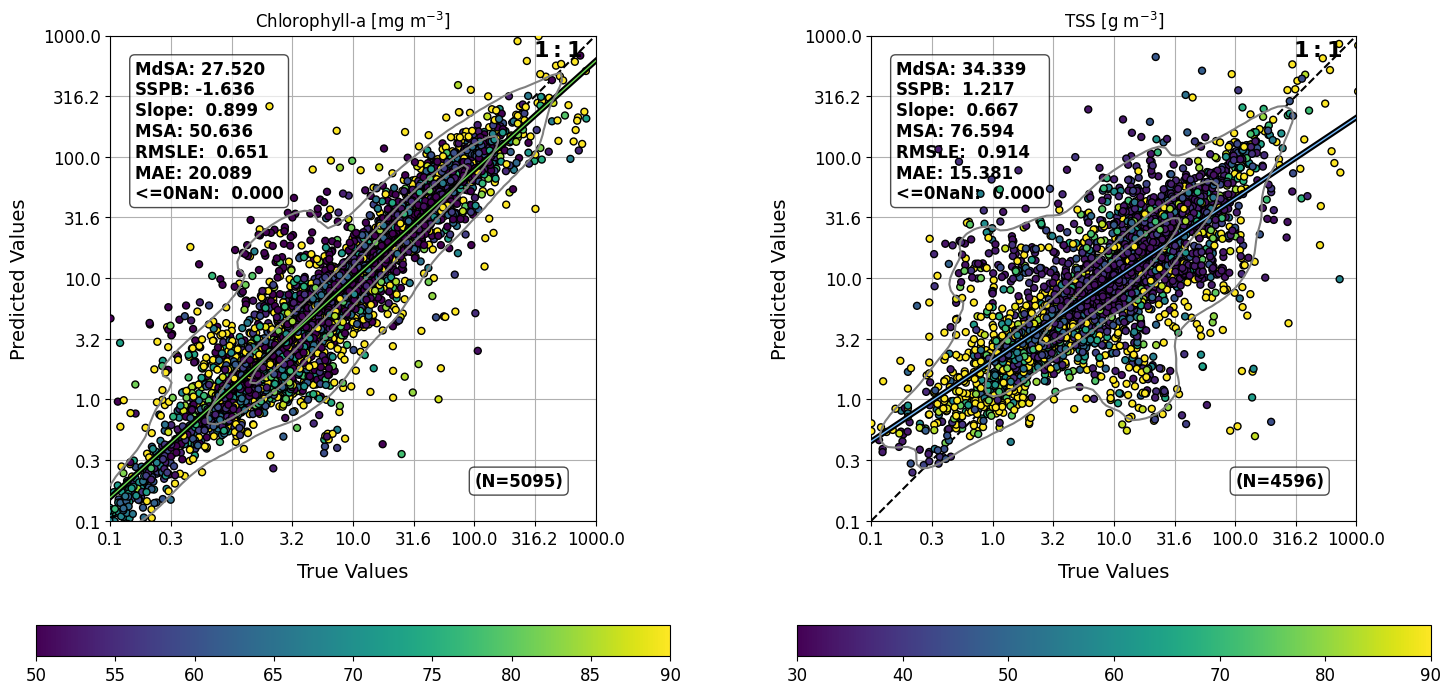

In [8]:
'Show a graphical comparision of the true and predicted values'
fig1 = create_scatterplots_trueVsPred(y_data, np.squeeze(wq_estimates['pred']), color=np.squeeze(uncert_perc), short_name=[r'Chlorophyll-a [$mg~m^{-3}$]', r'TSS [$g~m^{-3}$]'], 
                            x_label=['True Values', 'True Values'], y_label=['Predicted Values', 'Predicted Values'], inplot_str=inp_str,
                            title="", maxv_b=[3, 3], minv_b=[-1, -1], ipython_mode=True, vmin_b=[50., 30.], vmax_b=[90., 90.])

<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6; box-sizing: border-box; max-width: 100%; word-wrap: break-word; overflow-wrap: break-word;">

<h2 style="color: #c0392b; border-bottom: 2px solid #c0392b; padding-bottom: 8px; font-weight: 700; margin-top: 0;">
    Section 5: Comparing MDNs to operational products
</h2>

<p style="font-size: 1.15em; color: #222222;">
    As demonstrated in the previous section, the Mixture Density Networks (MDNs) yield highly reasonable and consistent predictions against validation measurements. To contextualize these performance gains, we next benchmark the MDN estimates directly against established operational ocean color algorithms.
</p>

<p style="font-size: 1.05em; color: #222222;">
    Specifically, we will evaluate MDN performance side-by-side with standard empirical and semi-analytical baselines:
</p>

<ul style="font-size: 1.05em; color: #222222; padding-left: 20px; margin-bottom: 20px;">
    <li style="margin-bottom: 10px;">
        <b>Chlorophyll-<i>a</i> Retrieval:</b> Benchmarking MDN outputs against the standard <b>OCv</b> (Ocean Color band-difference/ratio) algorithm.
    </li>
    <li style="margin-bottom: 10px;">
        <b>Total Suspended Solids (TSS):</b> Comparing MDN predictions directly against the operational <b>SOLID</b> algorithm.
    </li>
</ul>

<div style="background-color: #e8f4fd; color: #2b5797; padding: 15px; border: 1px solid #d2e3f7; border-left: 6px solid #2b5797; margin: 20px 0; box-sizing: border-box;">
    <strong style="font-size: 1.1em;">Technical Note:</strong> 
    Direct comparisons across optically complex waters demonstrate how machine learning architectures overcome traditional band-ratio limitations—particularly in regions prone to heavy CDOM absorption or suspended sediment backscattering where standard operational baselines often struggle.
</div>

<hr style="border: 0; border-top: 1px solid #eee; margin: 20px 0;">

<div style="font-size: 0.9em; color: #666; font-style: italic; text-align: right;">
    Aquaverse Short Course • Module 2.5
</div>

</div>

In [14]:
'Get predictions from the OC model'
wvl_bands =  get_sensor_bands(sensor="OLCI")
oc_preds_test = OC(x_data, wvl_bands, sensor="OLCI", algorithm='OC', num=3)

'Compare the true and predicted values and get a set of regression metrics for MDN on the test set'
inp_str_oc = []
key = "chl"
str2 = (performance(f'', y_data[:, wq_selected_slices[key]], np.squeeze(oc_preds_test)).replace('|', ''))
inp_str_oc += [str2.replace('   ', '\n')]
print(f"{key}:{str2}")


chl:            MdSA: 95.599   SSPB: 19.292   Slope:  0.626   MSA: 138.181   RMSLE:  1.158   MAE: 33.485   <=0NaN:  0.000


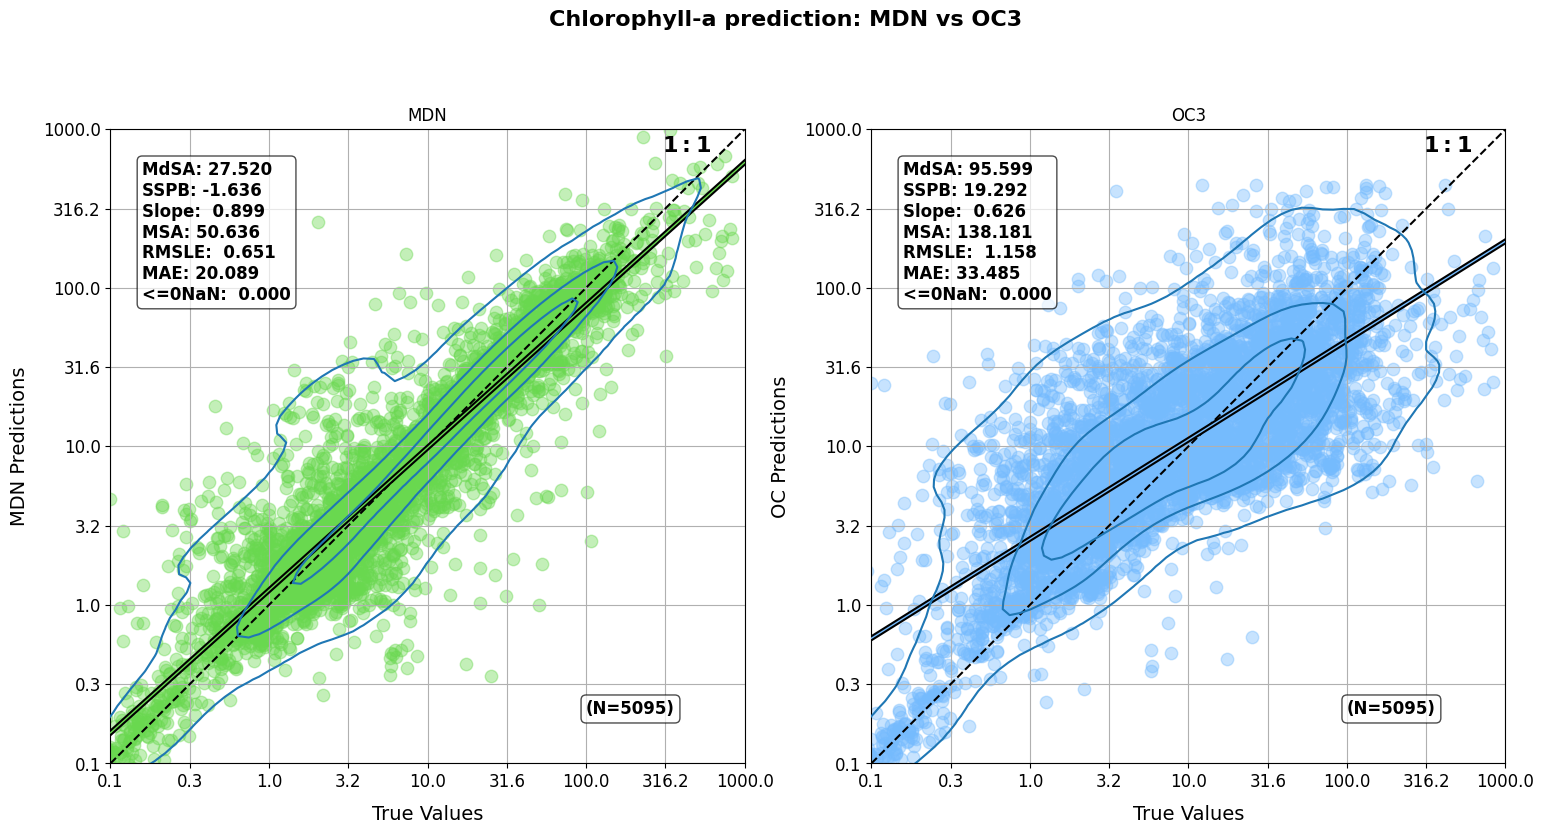

In [29]:
'Show a graphical comparision of the true and predicted values'
create_scatterplots_trueVsPred(np.vstack((y_data[:, 0], y_data[:, 0])).T, 
                                np.vstack((np.squeeze(wq_estimates['pred'][0, :, wq_selected_slices[key]]), np.squeeze(oc_preds_test))).T, 
                                short_name=[r'MDN', r'OC3'],
                                x_label=['True Values', 'True Values'], y_label=['MDN Predictions', 'OC Predictions'], 
                                inplot_str=[inp_str[0], inp_str_oc[0]],
                                title="Chlorophyll-a prediction: MDN vs OC3", maxv_b=[3, 3], minv_b=[-1, -1], ipython_mode=True)

<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6; box-sizing: border-box; max-width: 100%; word-wrap: break-word; overflow-wrap: break-word;">

<p style="font-size: 1.15em; color: #222222; margin-top: 0;">
    Evaluating the performance metrics clearly demonstrates that the <b>MDN model outperforms the standard operational OC4 algorithm</b> for Chlorophyll-<i>a</i> retrieval across the validation dataset.
</p>

<p style="font-size: 1.05em; color: #222222;">
    While empirical band-ratio algorithms like OC4 rely on blue-to-green reflectance ratios—which frequently fail in optically complex coastal and inland waters due to CDOM and sediment interference—the MDN leverages full spectral information to deliver significantly higher $R^2$ values alongside reduced RMSE and bias.
</p>

<div style="background-color: #e8f4fd; color: #2b5797; padding: 15px; border: 1px solid #d2e3f7; border-left: 6px solid #2b5797; margin: 20px 0; box-sizing: border-box;">
    <strong style="font-size: 1.1em;">Technical Note:</strong> 
    Notice how the scatter plot tightens around the 1:1 line for MDN predictions across both low and high concentration regimes, whereas OC4 exhibits pronounced saturation and scatter in turbid or highly colored waters.
</div>

<hr style="border: 0; border-top: 1px solid #eee; margin: 20px 0;">

</div>

<div style="padding: 25px; border: 2px solid #2c3e50; border-radius: 12px; background-color: #ffffff; color: #1a1a1a; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; line-height: 1.6; box-sizing: border-box; max-width: 100%; word-wrap: break-word; overflow-wrap: break-word;">

<h2 style="color: #004080; border-bottom: 3px solid #004080; padding-bottom: 10px; font-weight: 800; margin-top: 0;">
    Conclusion: Spectral Inversion & Validation
</h2>

<p style="font-size: 1.15em; color: #222222;">
    In this module, we walked through the complete workflow for generating, evaluating, and benchmarking water quality predictions from 2D spectral datasets using pre-trained <b>Mixture Density Networks (MDNs)</b>. By leveraging full-spectrum surface reflectances (<span style="font-family: 'Times New Roman', serif; font-weight: bold; font-style: italic; color: #000000;">R<sub style="font-style: normal; font-size: 0.75em; vertical-align: sub;">rs</sub></span>), you now have the tools to derive robust concentration estimates along with rigorous, normalized per-sample uncertainties.
</p>

<h3 style="color: #004080; margin-top: 25px;"><b>Key Takeaways</b></h3>
<ul style="line-height: 1.9; color: #1a1a1a; list-style-type: none; padding-left: 0;">
    <li><span style="color: #27ae60;">✔</span> <b>Automated Prediction:</b> Using <code>get_spectral_preds</code>, you auto-selected target models to process 2D spectral arrays into target water quality parameters and confidence bounds.</li>
    <li><span style="color: #27ae60;">✔</span> <b>Statistical Evaluation:</b> You computed comprehensive regression metrics (including $R^2$, RMSE, MAE, bias, and slope) across linear and log-transformed spaces.</li>
    <li><span style="color: #27ae60;">✔</span> <b>Uncertainty Visualization:</b> You created true vs. predicted scatter plots using normalized relative uncertainties to color-code each sample point and identify low-confidence regimes.</li>
    <li><span style="color: #27ae60;">✔</span> <b>Operational Benchmarking:</b> You verified that MDN models consistently outperform standard operational baselines—such as <b>OCv/OC4</b> for chlorophyll and <b>SOLID</b> for TSS—particularly in optically complex waters.</li>
</ul>

<div style="background-color: #e8f4fd; color: #2c3e50; padding: 15px; border: 1px solid #d1e9f9; border-left: 6px solid #004080; margin: 25px 0; box-sizing: border-box; max-width: 100%; word-wrap: break-word; overflow-wrap: break-word;">
    <strong style="font-size: 1.1em;">Up Next: Application to Satellite Data!</strong><br>
    Now that you have validated the core spectral inversion pipeline on 2D arrays, the next module will extend these exact principles to spatial raster data cubes. You will learn how to apply MDN models directly across full satellite scenes (such as Sentinel-3 OLCI) to generate high-resolution spatial water quality maps and uncertainty layers.
</div>

<hr style="border: 0; border-top: 2px solid #eee;">

<div style="display: flex; justify-content: space-between; align-items: center; margin-top: 20px;">
    <div>
        <strong style="color: #004080; font-size: 1.1em;">Freshwater Sensing Group</strong><br>
        <span style="color: #666; font-size: 0.95em;">SSAI / NASA Goddard Space Flight Center</span>
    </div>
    <div style="text-align: right;">
        <span style="font-size: 0.9em; color: #999; font-style: italic;">Aquaverse Short Course • End of Module 2</span><br>
        <a href="https://ladsweb.modaps.eosdis.nasa.gov/stream/" target="_blank" style="color: #0056b3; font-weight: bold; text-decoration: none; font-size: 0.9em;">Visit STREAM Website →</a>
    </div>
    

</div>